# PowerPlus — XGBoost Baseline, Decision Tree Comparison & 7/30-Day Forecasting

This corrected notebook **loads feature-engineered data, merges `daily_weather.csv` on City + date, and removes `House` from model features**.
It uses the existing processed files in `processed_data/`, preferring `powerplus_model_data.csv` (the dataset created by the Data Processing & Feature Engineering notebook), while also supporting `powerplus_forecast_features.csv` if that file is later created.

It will:
- train an XGBoost regression model with leakage-safe chronological splitting;
- compare XGBoost with the saved Decision Tree metrics from `powerplus_model_metrics.csv`;
- save the complete XGBoost preprocessing + model pipeline as a `.pkl`;
- generate **recursive 7-day and 30-day forecasts**;
- save the forecast outputs for later use by the user-input notebook.

> The recursive forecast uses future weather if you provide it. Otherwise it uses the same historical seasonal weather proxy approach as the existing Decision Tree forecasting notebook.

In [2]:
# 1. IMPORTS
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# 2. FIND PROJECT ROOT AND SELECT AN EXISTING PROCESSED DATASET

def find_project_root():
    candidates = [
        Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent,
        Path.cwd().parent.parent.parent,
    ]
    for p in candidates:
        if (p / "processed_data").exists():
            return p
    return Path.cwd()

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "processed_data"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: model_data.csv is the file your processing notebook actually creates.
# forecast_features.csv is supported if you create it later, but it is NOT required.
DATA_CANDIDATES = [
    PROCESSED_DIR / "powerplus_forecast_features.csv",
    PROCESSED_DIR / "powerplus_model_data.csv",
    PROCESSED_DIR / "powerplus_pre_decision_tree.csv",
]

DATA_FILE = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_FILE is None:
    raise FileNotFoundError(
        "No usable PowerPlus modeling dataset was found. Expected one of:" +
        "\n".join(str(p) for p in DATA_CANDIDATES)
    )


# Daily weather file is merged after loading the feature-engineered/model data.
WEATHER_FILE = PROCESSED_DIR / "daily_weather.csv"
if not WEATHER_FILE.exists():
    raise FileNotFoundError(
        f"Weather file not found: {WEATHER_FILE}. "
        "Place daily_weather.csv inside processed_data/."
    )

OUTPUT_DIR = PROCESSED_DIR / "ml_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_FILE:", DATA_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("WEATHER_FILE:", WEATHER_FILE)

PROJECT_ROOT: d:\Project-Electricity-Demand-Forecasting
DATA_FILE: d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_model_data.csv
OUTPUT_DIR: d:\Project-Electricity-Demand-Forecasting\processed_data\ml_outputs
WEATHER_FILE: d:\Project-Electricity-Demand-Forecasting\processed_data\daily_weather.csv


In [4]:
# 3. LOAD FEATURE-ENGINEERED DATA + MERGE DAILY WEATHER ON CITY + DATE

df = pd.read_csv(DATA_FILE)
weather_df = pd.read_csv(WEATHER_FILE)

DATE_CANDIDATES = ["date", "Date", "DATE"]
DATE_COL = next((c for c in DATE_CANDIDATES if c in df.columns), None)
if DATE_COL is None:
    raise ValueError("No date column found in model data.")

CITY_CANDIDATES = ["city", "City", "CITY"]
CITY_COL = next((c for c in CITY_CANDIDATES if c in df.columns), None)
if CITY_COL is None:
    raise ValueError("No city column found in model data.")

target_candidates = ["electricity_kwh", "Electricity_Consumption_kWh", "Electricity Consumption kWh"]
TARGET = next((c for c in target_candidates if c in df.columns), None)
if TARGET is None:
    raise ValueError(f"No electricity target found. Available columns: {list(df.columns)}")

weather_date_col = next((c for c in DATE_CANDIDATES if c in weather_df.columns), None)
weather_city_col = next((c for c in CITY_CANDIDATES if c in weather_df.columns), None)
if weather_date_col is None or weather_city_col is None:
    raise ValueError(
        "daily_weather.csv must contain City/city and date columns. "
        f"Available columns: {list(weather_df.columns)}"
    )

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
weather_df[weather_date_col] = pd.to_datetime(weather_df[weather_date_col], errors="coerce")

# Normalize merge keys while preserving the original City and date columns.
df["_merge_city"] = df[CITY_COL].astype(str).str.strip().str.casefold()
weather_df["_merge_city"] = weather_df[weather_city_col].astype(str).str.strip().str.casefold()
weather_df["_merge_date"] = weather_df[weather_date_col].dt.normalize()
df["_merge_date"] = df[DATE_COL].dt.normalize()

# Do not duplicate City/date columns from weather; keep weather variables only.
weather_value_cols = [
    c for c in weather_df.columns
    if c not in {weather_city_col, weather_date_col, "_merge_city", "_merge_date"}
]
# If weather has duplicate City+date records, aggregate numeric values by mean and keep first non-numeric.
weather_subset = weather_df[["_merge_city", "_merge_date"] + weather_value_cols].copy()
weather_subset = weather_subset.drop_duplicates(["_merge_city", "_merge_date"], keep="last")

existing = set(df.columns)
rename_map = {}
for c in weather_value_cols:
    if c in existing:
        rename_map[c] = f"{c}_weather"
weather_subset = weather_subset.rename(columns=rename_map)

df = df.merge(
    weather_subset,
    on=["_merge_city", "_merge_date"],
    how="left",
    validate="m:1"
).drop(columns=["_merge_city", "_merge_date"])

for c in df.columns:
    if pd.api.types.is_bool_dtype(df[c]):
        df[c] = df[c].astype(int)

df = df.dropna(subset=[DATE_COL, TARGET]).copy()
df = df.sort_values(DATE_COL).reset_index(drop=True)

merged_weather_cols = [rename_map.get(c, c) for c in weather_value_cols]
print("Model-data shape after weather merge:", df.shape)
print("Target:", TARGET)
print("Date range:", df[DATE_COL].min().date(), "to", df[DATE_COL].max().date())
print("Weather columns merged:", merged_weather_cols)
print("Weather match rate:", round(100 * df[merged_weather_cols].notna().any(axis=1).mean(), 2), "%")
display(df.head())


Model-data shape after weather merge: (19181, 105)
Target: electricity_kwh
Date range: 2023-08-15 to 2024-11-27
Weather columns merged: ['temperature_mean_weather', 'humidity_mean_weather', 'dew_mean_weather', 'wind_speed_mean_weather', 'wind_direction_mean_weather', 'pressure_mean_weather', 'solar_radiation_mean_weather', 'temperature_max_weather', 'humidity_max_weather', 'wind_speed_max_weather', 'solar_radiation_max_weather', 'uv_index_max_weather', 'precipitation_sum_weather', 'solar_energy_sum_weather']
Weather match rate: 100.0 %


,city,house,date,electricity_kwh,readings,avg_power_kw,max_power_kw,min_power_kw,expected_readings,coverage_pct,low_coverage_flag,House,City,Owner/Rented,No. of people (Temp+Perm),No. of Permanent residents,No. of Children (0-13),No. of Adults (14-60),No. of Seniors (above 60),No. of temporary residents,Property Area (Marla),Covered Area,No of Floors,Floor of Residency,Build year of house,Wapda Connection type,Average Ceiling Height ft,Ceiling Type,Roof Type,Flooring Type,Interior Wall,Exterior Wall,No. of rooms,Room Dimensions,Kitchen,Number of Washrooms,Number of Stores,Doors Type,Air Conditioners,Air Coolers,Refrigerators,Washing Machines,LED Bulbs,Tube Lights,Celling Fans,Wall Fans,Stand Fans,Water Dispensers,Water Pumps,Electric Cooker,Electric heaters,Electric Irons,Sewing Machine,Microwave Ovens,Geysers,UPS,Other Electronic Devices,temperature_mean,humidity_mean,dew_mean,wind_speed_mean,wind_direction_mean,pressure_mean,solar_radiation_mean,temperature_max,humidity_max,wind_speed_max,solar_radiation_max,uv_index_max,precipitation_sum,solar_energy_sum,year,month,day,day_of_week,week_of_year,day_of_year,is_weekend,season,lag_1_day_kwh,lag_2_day_kwh,lag_3_day_kwh,lag_7_day_kwh,lag_14_day_kwh,lag_30_day_kwh,rolling_3_day_avg_kwh,rolling_7_day_avg_kwh,rolling_14_day_avg_kwh,rolling_30_day_avg_kwh,house_age,total_appliance_count,temperature_mean_weather,humidity_mean_weather,dew_mean_weather,wind_speed_mean_weather,wind_direction_mean_weather,pressure_mean_weather,solar_radiation_mean_weather,temperature_max_weather,humidity_max_weather,wind_speed_max_weather,solar_radiation_max_weather,uv_index_max_weather,precipitation_sum_weather,solar_energy_sum_weather
0,Skardu,House#58,2023-08-15,0.002134,1,0.128050,0.128050,0.128050,1440,0.069444,1,House#58,Skardu,Owner,9.0,4.0,1.0,2.0,1.0,5.0,18.0,5.0,1,Whole,2000.0,1 phase,8.0,Fal Ceiling,Mud Plaster,Cemented,Painted,"Cemented, grey paint",4.0,"10*12,14*16",1.0,2.0,1.0,Wooden,0.0,0,1.0,1,11.0,2,3.0,0.0,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,18.5,96.30,17.9,2.5,46.4,1009.0,0.0,18.5,96.30,2.5,0.0,0,0.1,0.0,2023,8,15,1,33,227,0,Summer,0.002537,8.333333e-07,1.105278e-03,0.001577,0.011449,2.783333e-07,0.001214,0.001051,0.006987,0.004739,23.0,24.0,18.5,96.30,17.9,2.5,46.4,1009.0,0.0,18.5,96.30,2.5,0.0,0,0.1,0.0
1,Skardu,House#58,2023-08-16,0.002186,1,0.131150,0.131150,0.131150,1440,0.069444,1,House#58,Skardu,Owner,9.0,4.0,1.0,2.0,1.0,5.0,18.0,5.0,1,Whole,2000.0,1 phase,8.0,Fal Ceiling,Mud Plaster,Cemented,Painted,"Cemented, grey paint",4.0,"10*12,14*16",1.0,2.0,1.0,Wooden,0.0,0,1.0,1,11.0,2,3.0,0.0,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,22.1,87.89,20.0,2.2,48.2,1009.0,0.0,22.1,87.89,2.2,0.0,0,0.0,0.0,2023,8,16,2,33,228,0,Summer,0.002134,2.537222e-03,8.333333e-07,0.000873,0.022285,2.783333e-07,0.001557,0.001131,0.006322,0.004811,23.0,24.0,22.1,87.89,20.0,2.2,48.2,1009.0,0.0,22.1,87.89,2.2,0.0,0,0.0,0.0
2,Skardu,House#58,2023-08-17,0.001994,1,0.119667,0.119667,0.119667,1440,0.069444,1,House#58,Skardu,Owner,9.0,4.0,1.0,2.0,1.0,5.0,18.0,5.0,1,Whole,2000.0,1 phase,8.0,Fal Ceiling,Mud Plaster,Cemented,Painted,"Cemented, grey paint",4.0,"10*12,14*16",1.0,2.0,1.0,Wooden,0.0,0,1.0,1,11.0,2,3.0,0.0,1,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,20.8,80.89,17.4,3.6,42.3,1007.0,0.0,20.8,80.89,3.6,0.0,0,0.0,0.0,2023,8,17,3,33,229,0,Summer,0.002186,2.134167e-03,2.537222e-03,0.001251,0.023786,2.783333e-07,0.002286,0.001318,0.004886,0.004883,23.0,24.0,20.8,80.89,17.4,3.6,42.3,1007.0,0.0,20.8,80.89,3.6,0.0,0,0.0,0.0
3,Skardu,House#51,2023-08-18,0.002752,1,0.165117,0.165117,0.165117,1440,0.069444,1,House#51,Skardu,Owner,10.0,8.0,1.0,7.0,0.0,2.0,15.0,6.4,1,Whole,2002.0,1 phase,9.0,Cemented,Mud Plaster,Tiles,Painted,Painted,4.0,10*12,1.0,2.0,2.0,Wooden,0.0,0,1.0,1,8.0,0,2.0,0.0,0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,18.8,85.41,16.3,3.2,44.1,1008.0,0.0,18.8,85.41,3.2,0.0,0,0.0,0.0,2023,8,18,4,33,230,0,Summer,0.002495,7.222217e-06,2.523889e-03,0.003163,0.003323,0.000000e+00,0.001675,0.001683,0.005620,0.0030

## 4. Leakage-safe feature policy

The existing Decision Tree notebook excludes the target, the raw date, and same-day electricity measurement/coverage fields. We apply the same policy here. Historical lag and rolling demand features remain because they are based on information available before the prediction day.

In [5]:
# 5. DEFINE MODEL FEATURES

def norm(s):
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())

LEAKAGE_TOKENS = {
    "electricitykwh", "electricityconsumptionkwh", "readings",
    "avgpowerkw", "maxpowerkw", "minpowerkw", "expectedreadings",
    "coveragepct", "lowcoverageflag"
}

feature_columns = []
excluded_columns = []
for c in df.columns:
    n = norm(c)
    if c == DATE_COL or c == TARGET or any(tok in n for tok in LEAKAGE_TOKENS):
        excluded_columns.append(c)
    else:
        feature_columns.append(c)

# IMPORTANT: House is retained in the dataframe for household history/forecasting,
# but is intentionally excluded from the XGBoost model to improve generalization.
HOUSE_CANDIDATES = ["house", "House", "HOUSE"]
HOUSE_COL = next((c for c in HOUSE_CANDIDATES if c in df.columns), None)
if HOUSE_COL is not None and HOUSE_COL in feature_columns:
    feature_columns.remove(HOUSE_COL)
    excluded_columns.append(HOUSE_COL)
    print(f"Excluded House from model features: {HOUSE_COL}")

# Remove duplicated identifier columns when both variants are present.
for duplicate, keep in [("house_1", "house"), ("city_1", "city")]:
    if duplicate in feature_columns and keep in feature_columns:
        feature_columns.remove(duplicate)
        excluded_columns.append(duplicate)

numeric_features = [c for c in feature_columns if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in feature_columns if c not in numeric_features]

print("Model features:", len(feature_columns))
print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))
print("Historical demand features:", [c for c in feature_columns if "lag" in norm(c) or "rolling" in norm(c)])

Excluded House from model features: house
Model features: 95
Numeric: 81
Categorical: 14
Historical demand features: ['lag_1_day_kwh', 'lag_2_day_kwh', 'lag_3_day_kwh', 'lag_7_day_kwh', 'lag_14_day_kwh', 'lag_30_day_kwh', 'rolling_3_day_avg_kwh', 'rolling_7_day_avg_kwh', 'rolling_14_day_avg_kwh', 'rolling_30_day_avg_kwh']


In [6]:
# 6. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
unique_dates = np.sort(df[DATE_COL].unique())
if len(unique_dates) < 10:
    raise ValueError("At least 10 unique dates are required for the chronological split.")

outer_split = int(len(unique_dates) * 0.80)
TRAIN_END_DATE = pd.Timestamp(unique_dates[outer_split - 1])
TEST_START_DATE = pd.Timestamp(unique_dates[outer_split])

train_df = df[df[DATE_COL] <= TRAIN_END_DATE].copy()
test_df = df[df[DATE_COL] >= TEST_START_DATE].copy()

train_dates = np.sort(train_df[DATE_COL].unique())
inner_split = int(len(train_dates) * 0.80)
INNER_TRAIN_END_DATE = pd.Timestamp(train_dates[inner_split - 1])
VALID_START_DATE = pd.Timestamp(train_dates[inner_split])

inner_train = train_df[train_df[DATE_COL] <= INNER_TRAIN_END_DATE].copy()
valid_df = train_df[train_df[DATE_COL] >= VALID_START_DATE].copy()

print("Inner train:", inner_train[DATE_COL].min().date(), "to", inner_train[DATE_COL].max().date(), len(inner_train))
print("Validation :", valid_df[DATE_COL].min().date(), "to", valid_df[DATE_COL].max().date(), len(valid_df))
print("Test       :", test_df[DATE_COL].min().date(), "to", test_df[DATE_COL].max().date(), len(test_df))

Inner train: 2023-08-15 to 2024-06-09 11911
Validation : 2024-06-10 to 2024-08-24 4011
Test       : 2024-08-25 to 2024-11-27 3259


In [7]:
# 7. PREPROCESSOR AND EVALUATION
# Compatibility for older scikit-learn versions.
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), categorical_features),
], remainder="drop")

def evaluate(y_true, y_pred, name):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

X_inner_train, y_inner_train = inner_train[feature_columns], inner_train[TARGET]
X_valid, y_valid = valid_df[feature_columns], valid_df[TARGET]
X_train, y_train = train_df[feature_columns], train_df[TARGET]
X_test, y_test = test_df[feature_columns], test_df[TARGET]

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (15922, 95) X_test: (3259, 95)


In [8]:
# 8. SIMPLE BASELINES
baseline_rows = [evaluate(y_test, np.full(len(y_test), y_train.mean()), "Training Mean")]

for lag_name, label in [("lag_1_day_kwh", "Previous Day (lag_1)"), ("Lag_1", "Previous Day (Lag_1)"), ("lag_7_day_kwh", "Previous Week (lag_7)"), ("Lag_7", "Previous Week (Lag_7)")]:
    if lag_name in test_df.columns:
        mask = test_df[lag_name].notna()
        if mask.any():
            baseline_rows.append(evaluate(test_df.loc[mask, TARGET], test_df.loc[mask, lag_name], label))

baseline_results = pd.DataFrame(baseline_rows).drop_duplicates("model")
display(baseline_results.sort_values("MAE"))

,model,MAE,RMSE,R2
1,Previous Day (lag_1),0.091112,0.700165,0.887494
2,Previous Week (lag_7),0.138870,1.107834,0.718341
0,Training Mean,1.797734,2.446776,-0.373924


In [9]:
# 9. XGBOOST BASELINE
xgb_baseline = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_baseline),
])
baseline_pipeline.fit(X_train, y_train)
xgb_baseline_pred = baseline_pipeline.predict(X_test)
xgb_baseline_metrics = evaluate(y_test, xgb_baseline_pred, "XGBoost Baseline")
print(xgb_baseline_metrics)

{'model': 'XGBoost Baseline', 'MAE': 0.09701274897472024, 'RMSE': 0.749006276503976, 'R2': 0.8712506857837186}


In [10]:
# 10. COMPACT XGBOOST TUNING ON CHRONOLOGICAL VALIDATION
param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 6, 9],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# Keep the search practical: a fixed deterministic subset of the grid.
all_params = list(ParameterGrid(param_grid))
rng = np.random.default_rng(42)
if len(all_params) > 18:
    selected = rng.choice(len(all_params), size=18, replace=False)
    search_params = [all_params[i] for i in selected]
else:
    search_params = all_params

tuning_rows = []
for params in search_params:
    model = XGBRegressor(
        objective="reg:squarederror", random_state=42, n_jobs=-1,
        **params
    )
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_inner_train, y_inner_train)
    pred = pipe.predict(X_valid)
    tuning_rows.append({**params, "MAE": mean_absolute_error(y_valid, pred), "RMSE": np.sqrt(mean_squared_error(y_valid, pred)), "R2": r2_score(y_valid, pred)})

tuning_results = pd.DataFrame(tuning_rows).sort_values(["MAE", "RMSE"]).reset_index(drop=True)
BEST_PARAMS = tuning_results.iloc[0][["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree"]].to_dict()
BEST_PARAMS["n_estimators"] = int(BEST_PARAMS["n_estimators"])
BEST_PARAMS["max_depth"] = int(BEST_PARAMS["max_depth"])
print("Best parameters:", BEST_PARAMS)
display(tuning_results.head(10))

Best parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 1.0}


,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,MAE,RMSE,R2
0,1.0,0.03,3,300,0.8,0.353819,1.888001,0.913084
1,0.8,0.03,3,500,0.8,0.357575,1.878713,0.913937
2,1.0,0.03,3,500,0.8,0.369498,1.986907,0.903739
3,1.0,0.05,3,300,0.8,0.373515,1.963261,0.906016
4,0.8,0.03,3,500,1.0,0.390150,2.047985,0.897729
5,1.0,0.05,6,300,1.0,0.391705,2.012588,0.901234
6,0.8,0.05,3,500,0.8,0.392624,2.060546,0.896471
7,0.8,0.03,6,500,1.0,0.393840,1.991985,0.903246
8,0.8,0.05,9,300,1.0,0.395310,2.034869,0.899035
9,0.8,0.03,6,500,0.8,0.395790,2.036823,0.898841


In [11]:
# 11. FIT FINAL TUNED XGBOOST ON ALL TRAINING DATA
final_xgb = XGBRegressor(
    objective="reg:squarederror", random_state=42, n_jobs=-1,
    n_estimators=BEST_PARAMS["n_estimators"],
    max_depth=BEST_PARAMS["max_depth"],
    learning_rate=BEST_PARAMS["learning_rate"],
    subsample=BEST_PARAMS["subsample"],
    colsample_bytree=BEST_PARAMS["colsample_bytree"],
)

final_xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_xgb),
])
final_xgb_pipeline.fit(X_train, y_train)
final_xgb_pred = final_xgb_pipeline.predict(X_test)
final_xgb_metrics = evaluate(y_test, final_xgb_pred, "XGBoost Tuned")
print(final_xgb_metrics)

{'model': 'XGBoost Tuned', 'MAE': 0.09313794878900292, 'RMSE': 0.6847366230828195, 'R2': 0.8923978066996124}


In [12]:
# 12. LOAD AND COMPARE WITH EXISTING DECISION TREE RESULTS
DT_METRICS_FILE = PROCESSED_DIR / "powerplus_model_metrics.csv"
comparison_rows = list(baseline_rows) + [xgb_baseline_metrics, final_xgb_metrics]
comparison_source = "XGBoost + naive baselines"

if DT_METRICS_FILE.exists():
    dt_metrics = pd.read_csv(DT_METRICS_FILE)
    # Keep rows whose names identify the Decision Tree model(s).
    dt_rows = dt_metrics[dt_metrics.astype(str).apply(lambda col: col.str.contains("Decision Tree", case=False, na=False)).any(axis=1)].copy()
    for _, r in dt_rows.iterrows():
        row = {"model": r.get("model", "Decision Tree"), "MAE": r.get("MAE", np.nan), "RMSE": r.get("RMSE", np.nan), "R2": r.get("R2", np.nan)}
        comparison_rows.append(row)
    comparison_source = "Existing powerplus_model_metrics.csv"
else:
    print("WARNING: powerplus_model_metrics.csv not found; Decision Tree metrics cannot be imported.")

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.dropna(subset=["MAE", "RMSE", "R2"], how="any").drop_duplicates("model", keep="last").sort_values("MAE").reset_index(drop=True)
display(comparison)
print("Comparison source:", comparison_source)

,model,MAE,RMSE,R2
0,Previous Day (lag_1),0.091112,0.700165,0.887494
1,XGBoost Tuned,0.093138,0.684737,0.892398
2,XGBoost Baseline,0.097013,0.749006,0.871251
3,Decision Tree - Tuned,0.102742,0.765637,0.865470
4,Previous Week (lag_7),0.138870,1.107834,0.718341
5,Training Mean,1.797734,2.446776,-0.373924


Comparison source: Existing powerplus_model_metrics.csv


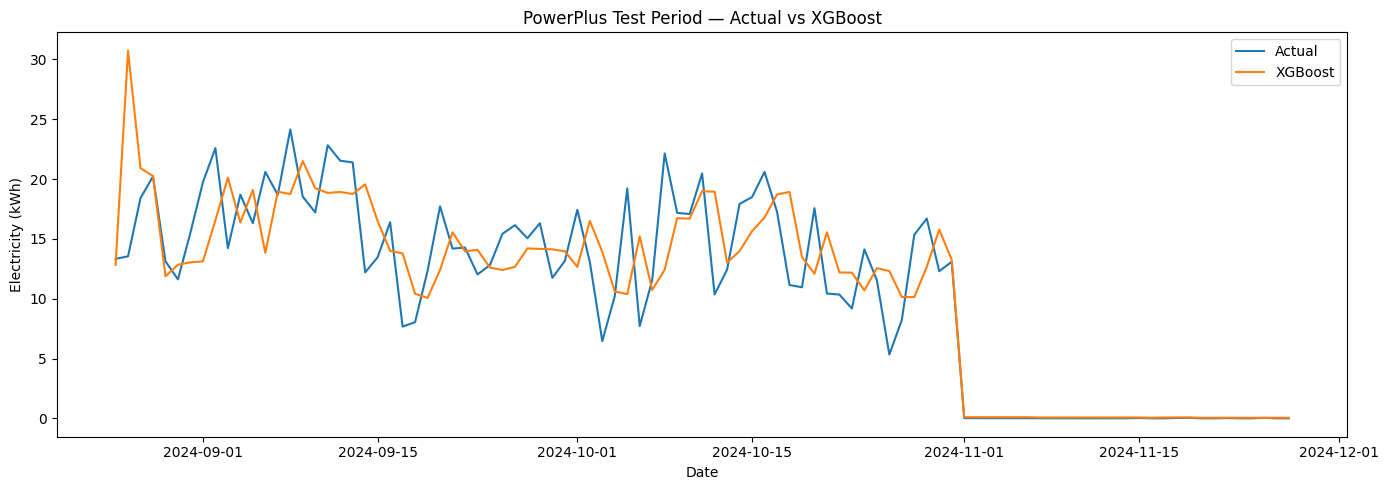

In [13]:
# 13. TEST-PERIOD ACTUAL VS XGBOOST
plot_df = test_df[[DATE_COL, TARGET]].copy()
plot_df["XGBoost"] = final_xgb_pred
daily_plot = plot_df.groupby(DATE_COL)[[TARGET, "XGBoost"]].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_plot[DATE_COL], daily_plot[TARGET], label="Actual")
plt.plot(daily_plot[DATE_COL], daily_plot["XGBoost"], label="XGBoost")
plt.title("PowerPlus Test Period — Actual vs XGBoost")
plt.xlabel("Date")
plt.ylabel("Electricity (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

,feature,importance
0,num__rolling_3_day_avg_kwh,0.503368
1,num__rolling_7_day_avg_kwh,0.180786
2,num__lag_1_day_kwh,0.092808
3,num__rolling_14_day_avg_kwh,0.040308
4,num__rolling_30_day_avg_kwh,0.037442
5,num__lag_2_day_kwh,0.018998
6,num__dew_mean,0.009215
7,num__No. of people (Temp+Perm),0.009070
8,num__week_of_year,0.008764
9,num__day_of_year,0.008503


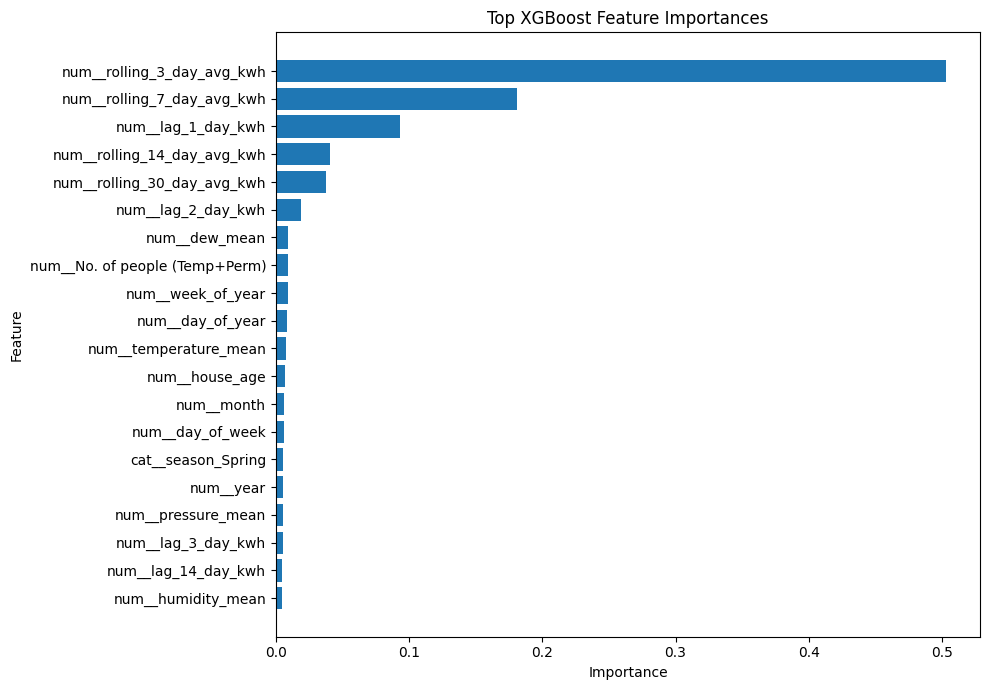

In [14]:
# 14. XGBOOST FEATURE IMPORTANCE
fitted_preprocessor = final_xgb_pipeline.named_steps["preprocessor"]
fitted_model = final_xgb_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({"feature": feature_names, "importance": fitted_model.feature_importances_}).sort_values("importance", ascending=False).reset_index(drop=True)
display(importance_df.head(30))

top = importance_df.head(20).sort_values("importance")
plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["importance"])
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Recursive 7-day and 30-day forecasting

This section follows the same design as the existing Decision Tree notebook: future target values are never used. Each prediction is appended to the household's demand history and is then available for later lag/rolling calculations.

In [15]:
# 16. FORECAST DEFINITIONS AND WEATHER PROXY
WEATHER_COLUMNS = [
    "temperature_mean", "humidity_mean", "dew_mean", "wind_speed_mean",
    "wind_direction_mean", "pressure_mean", "solar_radiation_mean",
    "temperature_max", "humidity_max", "wind_speed_max", "solar_radiation_max",
    "uv_index_max", "precipitation_sum", "solar_energy_sum",
]
LAG_MAP = {lag: next((c for c in [f"lag_{lag}_day_kwh", f"Lag_{lag}", f"lag_{lag}"] if c in df.columns), None) for lag in [1,2,3,7,14,30]}
ROLLING_MAP = {w: next((c for c in [f"rolling_{w}_day_avg_kwh", f"Rolling_{w}", f"rolling_{w}"] if c in df.columns), None) for w in [3,7,14,30]}
CITY_COL = "city" if "city" in df.columns else ("City" if "City" in df.columns else None)
HOUSE_COL = "house" if "house" in df.columns else ("House" if "House" in df.columns else None)

if CITY_COL is None or HOUSE_COL is None:
    raise ValueError("Recursive 7/30-day forecasting requires city and house columns.")
if not any(LAG_MAP.values()):
    raise ValueError("Recursive forecasting requires at least one lag feature.")

def season_from_month(month):
    if month in [12, 1, 2]: return "Winter"
    if month in [3, 4, 5]: return "Spring"
    if month in [6, 7, 8]: return "Summer"
    return "Autumn"

def build_seasonal_weather_proxy(history, dates, city):
    h = history.copy()
    h["_doy"] = h[DATE_COL].dt.dayofyear
    h["_month"] = h[DATE_COL].dt.month
    ch = h[h[CITY_COL] == city]
    rows=[]
    for d in dates:
        exact = ch[ch["_doy"] == d.dayofyear]
        source = exact if len(exact) else ch[ch["_month"] == d.month]
        row={CITY_COL: city, DATE_COL: d}
        for c in WEATHER_COLUMNS:
            if c in df.columns:
                vals = source[c].dropna() if c in source.columns else pd.Series(dtype=float)
                row[c] = vals.mean() if len(vals) else df[c].median()
        rows.append(row)
    return pd.DataFrame(rows)

def prepare_future_weather(history, city, dates, future_weather=None):
    proxy = build_seasonal_weather_proxy(history, dates, city)
    if future_weather is None:
        print("Using HISTORICAL SEASONAL WEATHER PROXY — not a real weather forecast.")
        return proxy
    fw = future_weather.copy()
    if "date" in fw.columns:
        fw["date"] = pd.to_datetime(fw["date"], errors="coerce")
    fw_city_col = CITY_COL if CITY_COL in fw.columns else ("city" if "city" in fw.columns else None)
    if fw_city_col is None or "date" not in fw.columns:
        raise ValueError("Future weather must contain city and date columns.")
    fw = fw[fw[fw_city_col] == city]
    fw = fw[fw["date"].isin(dates)].copy()
    if fw_city_col != CITY_COL:
        fw = fw.rename(columns={fw_city_col: CITY_COL})
    merged = proxy.merge(fw, on=[CITY_COL, DATE_COL], how="left", suffixes=("_proxy", ""))
    for c in WEATHER_COLUMNS:
        if c in df.columns:
            if c not in merged.columns:
                merged[c] = merged[f"{c}_proxy"]
            else:
                merged[c] = merged[c].combine_first(merged[f"{c}_proxy"])
            if f"{c}_proxy" in merged.columns:
                merged.drop(columns=[f"{c}_proxy"], inplace=True)
    return merged

FUTURE_WEATHER_FILE = None  # Optional CSV with city/date + weather columns.
future_weather = pd.read_csv(FUTURE_WEATHER_FILE) if FUTURE_WEATHER_FILE else None
if future_weather is not None and "date" in future_weather.columns:
    future_weather["date"] = pd.to_datetime(future_weather["date"], errors="coerce")

print("City:", CITY_COL, "House:", HOUSE_COL)
print("Lag map:", LAG_MAP)
print("Rolling map:", ROLLING_MAP)

City: city House: house
Lag map: {1: 'lag_1_day_kwh', 2: 'lag_2_day_kwh', 3: 'lag_3_day_kwh', 7: 'lag_7_day_kwh', 14: 'lag_14_day_kwh', 30: 'lag_30_day_kwh'}
Rolling map: {3: 'rolling_3_day_avg_kwh', 7: 'rolling_7_day_avg_kwh', 14: 'rolling_14_day_avg_kwh', 30: 'rolling_30_day_avg_kwh'}


In [16]:
# 17. RECURSIVE FORECAST ENGINE

def add_calendar(row, d):
    values = {
        "year": d.year, "month": d.month, "day": d.day,
        "day_of_week": d.dayofweek, "week_of_year": int(d.isocalendar().week),
        "day_of_year": d.dayofyear, "is_weekend": int(d.dayofweek >= 5),
        "season": season_from_month(d.month),
    }
    for k, v in values.items():
        if k in feature_columns:
            row[k] = v
    return row

def recursive_forecast_xgb(city, house, horizon_days=7, start_date=None, future_weather=None):
    if start_date is None:
        start_date = df[DATE_COL].max() + pd.Timedelta(days=1)
    start_date = pd.Timestamp(start_date)
    if start_date <= df[DATE_COL].max():
        raise ValueError("start_date must be after the last historical date.")

    hh = df[(df[CITY_COL] == city) & (df[HOUSE_COL] == house)].sort_values(DATE_COL).copy()
    if hh.empty:
        raise ValueError(f"No history found for city={city!r}, house={house!r}")

    profile = hh.iloc[-1].to_dict()
    demand = hh[[DATE_COL, TARGET]].copy().dropna()
    dates = pd.date_range(start_date, periods=horizon_days, freq="D")
    weather = prepare_future_weather(df, city, dates, future_weather)
    results=[]

    for d in dates:
        row = profile.copy()
        row[CITY_COL] = city
        row[HOUSE_COL] = house
        row = add_calendar(row, d)

        # Update a common house-age feature if present.
        if "build_year_of_house" in row and "house_age" in feature_columns and pd.notna(row["build_year_of_house"]):
            row["house_age"] = d.year - float(row["build_year_of_house"])

        wm = weather[weather[CITY_COL] == city]
        wm = wm[wm[DATE_COL] == d]
        if not wm.empty:
            wr = wm.iloc[0]
            for c in WEATHER_COLUMNS:
                if c in feature_columns and c in wr.index and pd.notna(wr[c]):
                    row[c] = wr[c]

        # Historical lags: actual values first, then prior predictions.
        for lag, col in LAG_MAP.items():
            if col is None: continue
            target_date = d - pd.Timedelta(days=lag)
            m = demand[demand[DATE_COL] == target_date]
            row[col] = float(m[TARGET].iloc[-1]) if not m.empty else float(demand[TARGET].iloc[-1])

        past = demand[demand[DATE_COL] < d].sort_values(DATE_COL)[TARGET]
        for window, col in ROLLING_MAP.items():
            if col is not None:
                row[col] = float(past.tail(window).mean()) if len(past) else float(demand[TARGET].mean())

        X_future = pd.DataFrame([row]).reindex(columns=feature_columns)
        pred = max(0.0, float(final_xgb_pipeline.predict(X_future)[0]))
        results.append({"date": d, "city": city, "house": house, "predicted_electricity_kwh": pred})
        demand = pd.concat([demand, pd.DataFrame([{DATE_COL: d, TARGET: pred}])], ignore_index=True)

    return pd.DataFrame(results)

In [17]:
# 18. GENERATE 7-DAY AND 30-DAY FORECASTS
example = df[[CITY_COL, HOUSE_COL]].drop_duplicates().sort_values([CITY_COL, HOUSE_COL]).iloc[0]
FORECAST_CITY = example[CITY_COL]
FORECAST_HOUSE = example[HOUSE_COL]
FORECAST_START_DATE = df[DATE_COL].max() + pd.Timedelta(days=1)

forecast_7 = recursive_forecast_xgb(FORECAST_CITY, FORECAST_HOUSE, horizon_days=7, start_date=FORECAST_START_DATE, future_weather=future_weather)
forecast_30 = recursive_forecast_xgb(FORECAST_CITY, FORECAST_HOUSE, horizon_days=30, start_date=FORECAST_START_DATE, future_weather=future_weather)

print("7-day forecast:")
display(forecast_7)
print("7-day total:", round(forecast_7["predicted_electricity_kwh"].sum(), 4), "kWh")

print("30-day forecast:")
display(forecast_30)
print("30-day total:", round(forecast_30["predicted_electricity_kwh"].sum(), 4), "kWh")

Using HISTORICAL SEASONAL WEATHER PROXY — not a real weather forecast.
Using HISTORICAL SEASONAL WEATHER PROXY — not a real weather forecast.
7-day forecast:


,date,city,house,predicted_electricity_kwh
0,2024-11-28,Islamabad,House#41,0.024284
1,2024-11-29,Islamabad,House#41,0.024284
2,2024-11-30,Islamabad,House#41,0.024284
3,2024-12-01,Islamabad,House#41,0.024284
4,2024-12-02,Islamabad,House#41,0.024284
5,2024-12-03,Islamabad,House#41,0.024284
6,2024-12-04,Islamabad,House#41,0.024284


7-day total: 0.17 kWh
30-day forecast:


,date,city,house,predicted_electricity_kwh
0,2024-11-28,Islamabad,House#41,0.024284
1,2024-11-29,Islamabad,House#41,0.024284
2,2024-11-30,Islamabad,House#41,0.024284
3,2024-12-01,Islamabad,House#41,0.024284
4,2024-12-02,Islamabad,House#41,0.024284
5,2024-12-03,Islamabad,House#41,0.024284
6,2024-12-04,Islamabad,House#41,0.024284
7,2024-12-05,Islamabad,House#41,0.024284
8,2024-12-06,Islamabad,House#41,0.024284
9,2024-12-07,Islamabad,House#41,0.024284


30-day total: 0.7285 kWh


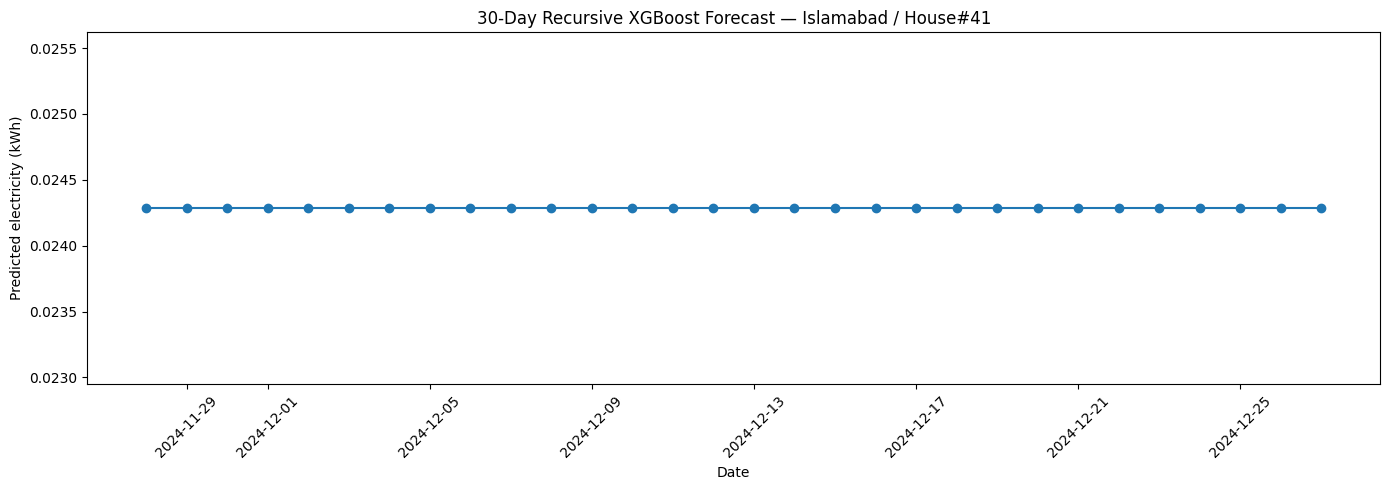

In [18]:
# 19. FORECAST PLOT
plt.figure(figsize=(14, 5))
plt.plot(forecast_30["date"], forecast_30["predicted_electricity_kwh"], marker="o")
plt.title(f"30-Day Recursive XGBoost Forecast — {FORECAST_CITY} / {FORECAST_HOUSE}")
plt.xlabel("Date")
plt.ylabel("Predicted electricity (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# 20. SAVE MODEL, METRICS, IMPORTANCE AND FORECASTS
MODEL_PKL = PROCESSED_DIR / "powerplus_xgboost_forecast_model.pkl"
METRICS_OUT = PROCESSED_DIR / "powerplus_xgboost_model_metrics.csv"
TUNING_OUT = PROCESSED_DIR / "powerplus_xgboost_tuning_results.csv"
IMPORTANCE_OUT = PROCESSED_DIR / "powerplus_xgboost_feature_importance.csv"
FORECAST_7_OUT = PROCESSED_DIR / "powerplus_xgboost_forecast_7_day.csv"
FORECAST_30_OUT = PROCESSED_DIR / "powerplus_xgboost_forecast_30_day.csv"
CONFIG_OUT = PROCESSED_DIR / "powerplus_xgboost_model_config.json"

artifact = {
    "pipeline": final_xgb_pipeline,
    "target": TARGET,
    "date_column": DATE_COL,
    "city_column": CITY_COL,
    "house_column": HOUSE_COL,
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "excluded_columns": excluded_columns,
    "train_end_date": str(TRAIN_END_DATE.date()),
    "test_start_date": str(TEST_START_DATE.date()),
    "best_parameters": BEST_PARAMS,
    "data_file": str(DATA_FILE),
    "weather_file": str(WEATHER_FILE),
    "weather_merge_keys": {"city": CITY_COL, "date": DATE_COL},
}
joblib.dump(artifact, MODEL_PKL)
comparison.to_csv(METRICS_OUT, index=False)
tuning_results.to_csv(TUNING_OUT, index=False)
importance_df.to_csv(IMPORTANCE_OUT, index=False)
forecast_7.to_csv(FORECAST_7_OUT, index=False)
forecast_30.to_csv(FORECAST_30_OUT, index=False)

config = {k:v for k,v in artifact.items() if k != "pipeline"}
with open(CONFIG_OUT, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, default=str)

print("Saved:")
for p in [MODEL_PKL, METRICS_OUT, TUNING_OUT, IMPORTANCE_OUT, FORECAST_7_OUT, FORECAST_30_OUT, CONFIG_OUT]:
    print(" -", p)

Saved:
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_forecast_model.pkl
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_model_metrics.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_tuning_results.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_feature_importance.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_forecast_7_day.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_forecast_30_day.csv
 - d:\Project-Electricity-Demand-Forecasting\processed_data\powerplus_xgboost_model_config.json


In [20]:
# 21. FINAL CHECK
print("=" * 70)
print("POWERPLUS XGBOOST — FINAL CHECK")
print("=" * 70)
print("Training source:", DATA_FILE.name)
print("Target:", TARGET)
print("Train end:", TRAIN_END_DATE.date())
print("Test start:", TEST_START_DATE.date())
print("Features:", len(feature_columns))
print("XGBoost metrics:", final_xgb_metrics)
print("7-day total kWh:", round(forecast_7["predicted_electricity_kwh"].sum(), 4))
print("30-day total kWh:", round(forecast_30["predicted_electricity_kwh"].sum(), 4))
display(comparison)

POWERPLUS XGBOOST — FINAL CHECK
Training source: powerplus_model_data.csv
Target: electricity_kwh
Train end: 2024-08-24
Test start: 2024-08-25
Features: 95
XGBoost metrics: {'model': 'XGBoost Tuned', 'MAE': 0.09313794878900292, 'RMSE': 0.6847366230828195, 'R2': 0.8923978066996124}
7-day total kWh: 0.17
30-day total kWh: 0.7285


,model,MAE,RMSE,R2
0,Previous Day (lag_1),0.091112,0.700165,0.887494
1,XGBoost Tuned,0.093138,0.684737,0.892398
2,XGBoost Baseline,0.097013,0.749006,0.871251
3,Decision Tree - Tuned,0.102742,0.765637,0.865470
4,Previous Week (lag_7),0.138870,1.107834,0.718341
5,Training Mean,1.797734,2.446776,-0.373924
